# **Initial Data Preparation Notebook**

## Table of Contents

1. [Setup](#1-setup)
2. [Data Preparation Pipeline](#2-data-preparation-pipeline)
3. [Exploratory Analysis](#3-exploratory-analysis)
   - [3.1 Schema & Statistics](#31-schema--statistics)
   - [3.2 Missing Values](#32-missing-values)
   - [3.3 Target Variable (AHI)](#33-target-variable-ahi)

## 1. Setup

In [ ]:
# importing libraries

# ── data & numeric ────────────────────────────────────────────────────────────
import os
import time
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from numpy.linalg import slogdet

# ── stats ─────────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.optimize import minimize
from scipy.stats import randint, uniform

# ── ML ────────────────────────────────────────────────────────────────────────
import joblib
import shap
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    ConfusionMatrixDisplay, f1_score, precision_recall_curve,
    PrecisionRecallDisplay, roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.data
import mlflow.sklearn
from factor_analyzer import (
    ConfirmatoryFactorAnalyzer, FactorAnalyzer,
    ModelSpecification, ModelSpecificationParser,
)

# ── project ───────────────────────────────────────────────────────────────────
from src.features import raw_data_loader, feature_encoder
from src.features.irt_scorer import grm_score_eap
from src.features.transformers import int_transform as _int_transform
from src.modeling.eval import plot_permutation_importance
from src.utils.data_utils import ahi_to_severity, check_sentinel_values, convert_ahi
from src.visualization.plots import efa_elbow_plot

# ── project root (walk up from cwd until pyproject.toml is found) ─────────────
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())


In [53]:
# loading
RAW_DATASET = "data/raw/stages/datasets/stages-dataset-0.3.0.csv"
DATA_DICT = "data/raw/stages/datasets/stages-data-dictionary-0.3.0-variables.csv"
AHI_EXCEL = (
    "data/raw/stages/original/De-identified Data/"
    "PSG SRBD Variables/"
    "STAGESPSGKeySRBDVariables2020-08-29 Deidentified.xlsx"
)

stages_raw = pd.read_csv(PROJECT_ROOT / RAW_DATASET)
data_dict = pd.read_csv(PROJECT_ROOT / DATA_DICT)

In [54]:
# build display-name mapping
display_names = data_dict.set_index("id")["display_name"].to_dict()
stripped = raw_data_loader.strip_text(list(display_names.values()))
keys = list(display_names.keys())
name_map = {keys[i]: stripped[i] for i in range(len(keys))}

# get target (apnea-hypopnea index) from sleep study file
output_df = pd.read_excel(PROJECT_ROOT / AHI_EXCEL)
output_df = output_df[["s_code", "ahi"]]
output_df = output_df.rename(columns={"s_code": "subject_code"})

In [55]:
# build subset map: original_col_id → subset_name

_LABEL_SUBSETS = {
    "parasomnias": ["hypnogogic_hallucinations", "bruxism", "sleep_paralysis", "nightmare", "sleepwalk"],
    "sleep_patterns": ["sleep_latency", "sleep_quality", "sleep_satisfaction", "sleep_duration",
                       "sleep_timing", "sleep_hygiene", "sleep_eat", "subject_sleepiness"],
    "rls": ["rls_plms"],
    "narc": ["narcolepsy"],
    "insomnia": ["insomnia"],
}

fl = data_dict[["folder", "labels", "id"]].set_index("id")
subsets = {}

for name, labels in _LABEL_SUBSETS.items():
    subsets[name] = fl[fl["labels"].isin(labels)].index.tolist()

subsets["demographics"] = fl[
    fl["folder"].str.startswith("Demographics", na=False) |
    fl["folder"].str.startswith("Anthropometry", na=False)
].index.tolist()
subsets["health"] = fl[fl["folder"].str.contains("Health", na=False)].index.tolist()
subsets["medhx"] = fl[fl["folder"].str.startswith("Medical History", na=False)].index.tolist()
subsets["sleep_questions"] = fl[fl["folder"].str.startswith("Sleep Questionnaires", na=False)].index.tolist()
subsets["sleep_treatment"] = fl[fl["folder"].str.startswith("Sleep Treatment", na=False)].index.tolist()

# de-duplicate (same priority order as source)
subsets["sleep_patterns"] = [c for c in subsets["sleep_patterns"] if c not in subsets["health"]]
subsets["sleep_questions"] = [c for c in subsets["sleep_questions"] if c not in subsets["parasomnias"]]
subsets["sleep_questions"] = [c for c in subsets["sleep_questions"] if c not in subsets["sleep_patterns"]]
subsets["health"] = [c for c in subsets["health"] if c not in subsets["medhx"]]
subsets["insomnia"] = [c for c in subsets["insomnia"] if c not in subsets["health"]]
for excl in ("rls", "narc", "insomnia"):
    subsets["sleep_questions"] = [c for c in subsets["sleep_questions"] if c not in subsets[excl]]

_SUBSET_PRIORITY = ["parasomnias", "sleep_patterns", "demographics", "health", "medhx",
                    "rls", "narc", "insomnia", "sleep_questions", "sleep_treatment"]

# flat map: col_id → subset_name (first match wins)
subset_map = {}
for name in _SUBSET_PRIORITY:
    for col in subsets[name]:
        subset_map.setdefault(col, name)

## 2. Data Preparation Pipeline

In [56]:
# merge AHI target + initial row-level cleaning

df = stages_raw.merge(output_df[["subject_code", "ahi"]], on="subject_code", how="inner")

# register ahi in lookup maps
name_map["ahi"] = "apnea_hypopnea_index"
subset_map["ahi"] = "output"

# drop columns not assigned to any subset
assigned = set(subset_map)
df = df[[c for c in df.columns if c in assigned]]

n_before = len(df)
df = df.drop_duplicates()
n_after_dedup = len(df)
df = df.dropna(how="all")
n_after_dropna = len(df)

print(f"Rows before cleaning:  {n_before}")
print(f"Duplicate rows dropped: {n_before - n_after_dedup}")
print(f"All-NA rows dropped:    {n_after_dedup - n_after_dropna}")
print(f"Final shape: {df.shape}")

Rows before cleaning:  1651
Duplicate rows dropped: 7
All-NA rows dropped:    0
Final shape: (1644, 430)


In [57]:
_DEMOGRAPHICS_DROP_INITIAL = [
    "dem_0100", "dem_0900", "dem_0910", "dem_1000", "dem_1010",
    "dem_1100", "dem_1120", "sched_0100",
]
_DEMOGRAPHICS_DROP_AFTER_COMBINE = [
    "sched_0200", "sched_0300", "sched_0700", "sched_0400", "sched_0800",
    "sched_0301", "sched_0401", "sched_0500", "sched_0510",
    "sched_0600", "sched_1100", "sched_1200", "sched_1500", "sched_1501",
    "sched_1600", "sched_2100", "dem_0600",
]

print("Dropped immediately (bias/redundancy):")
for col in _DEMOGRAPHICS_DROP_INITIAL:
    print(f"  {col:20s}  {name_map.get(col, '(no display name)')}")

print("\nDropped after combining:")
for col in _DEMOGRAPHICS_DROP_AFTER_COMBINE:
    print(f"  {col:20s}  {name_map.get(col, '(no display name)')}")

Dropped immediately (bias/redundancy):
  dem_0100              participants_year_of_birth
  dem_0900              participants_ethnicity_(hispanic_or_latino)
  dem_0910              participants_ethnicity_(sub_hispanic_or_latino_origin)
  dem_1000              participants_race_(main)
  dem_1010              participants_race_(sub)
  dem_1100              english_as_native_language
  dem_1120              participants_proficiency_in_english
  sched_0100            level_of_school

Dropped after combining:
  sched_0200            days_per_week_in_school
  sched_0300            time_school_starts
  sched_0700            self-reported_work_start_time_current_shift
  sched_0400            time_school_ends
  sched_0800            self-reported_work_end_time_current_shift
  sched_0301            time_school_starts_varies
  sched_0401            time_school_ends_varies
  sched_0500            regular_or_irregular_work_schedule
  sched_0510            do_you_work_a_split_shift
  sched_0600    

In [58]:
# demographics engineering

_DEMOGRAPHICS_INT_COLS = [
    "modified_dem_0110", "dem_0610", "bthbts_0500", "bthbts_0510",
    "bthbts_0520", "bthbts_0530", "bthbts_0540", "sched_9900",
]

# drop bias/redundancy columns
df = df.drop(columns=[c for c in _DEMOGRAPHICS_DROP_INITIAL if c in df.columns])

# combined days_per_week_in_school_or_work
school_work_cols = [c for c in ("sched_0200", "sched_0600") if c in df.columns]
df["sched_9900"] = df[school_work_cols].max(axis=1)
name_map["sched_9900"] = "days_per_week_in_school_or_work"
subset_map["sched_9900"] = "demographics"

# irregular_schedule
vary_cols = [c for c in ("sched_0301", "sched_0401", "sched_0500", "sched_0510") if c in df.columns]
df["sched_9910"] = df[vary_cols].max(axis=1)
name_map["sched_9910"] = "irregular_schedule"
subset_map["sched_9910"] = "demographics"

# combined school/work start and end times
for col in ("sched_0300", "sched_0700", "sched_0400", "sched_0800"):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", format="%H:%M:%S")

start_cols = [c for c in ("sched_0300", "sched_0700") if c in df.columns]
df["sched_9911"] = df[start_cols].min(axis=1)
name_map["sched_9911"] = "time_school_or_work_starts"
subset_map["sched_9911"] = "demographics"

end_cols = [c for c in ("sched_0400", "sched_0800") if c in df.columns]
df["sched_9920"] = df[end_cols].max(axis=1)
name_map["sched_9920"] = "time_school_or_work_ends"
subset_map["sched_9920"] = "demographics"

# height: fold feet into inches
if "dem_0600" in df.columns and "dem_0610" in df.columns:
    df["dem_0610"] = df["dem_0610"] + (df["dem_0600"] * 12)

# drop consumed columns
df = df.drop(columns=[c for c in _DEMOGRAPHICS_DROP_AFTER_COMBINE if c in df.columns])

# type conversions
for c in _DEMOGRAPHICS_INT_COLS:
    if c in df.columns:
        df[c] = df[c].astype("Int64")
if "sched_9910" in df.columns:
    df["sched_9910"] = df["sched_9910"].astype("boolean")

print(df.shape)

(1644, 409)


In [59]:
# datetime conversions for sleep patterns and health subsets

_SLEEP_PATTERNS_DT_COLS = [
    "sched_0900", "sched_1000", "sched_1300", "sched_1400",
    "sched_1700", "sched_1800", "sched_1900", "sched_2000",
]
_HEALTH_DT_COLS = [
    "soclhx_1000", "diet_0870", "diet_0860", "diet_0850",
    "diet_0840", "diet_0830", "diet_0820", "diet_0810", "diet_0800",
]

for col in _SLEEP_PATTERNS_DT_COLS + _HEALTH_DT_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", format="%H:%M:%S")

In [60]:
# rename for display; df retains original IDs for programmatic use
df_display = df.rename(columns=name_map)
df_display.head()

,participants_age,participants_sex,height_in_inches,weight_in_pounds,body_mass_index_(bmi),previously_been_to_a_sleep_specialist,type_of_pap_device,frequency_of_pap_use,on_nights_pap_was_used_how_many_hours_of_pap_use,pregnancy_current,...,cigarette_smoking_never_smoker,cigarette_smoking_former_smoker,smokeless_user_former_smoker,cigarette_smoking_current_smoker,smokeless_user_current_smoker,apnea_hypopnea_index,days_per_week_in_school_or_work,irregular_schedule,time_school_or_work_starts,time_school_or_work_ends
0,30,F,67,188.0,29.4,1.0,NaN,NaN,NaN,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,<NA>,False,1900-01-01 08:00:00,1900-01-01 17:00:00
1,30,F,67,165.0,25.8,1.0,NaN,NaN,NaN,0.0,...,1.0,0.0,0.0,0.0,0.0,2.5,3,True,1900-01-01 07:00:00,1900-01-01 19:00:00
2,42,M,64,156.0,26.8,1.0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,6.0,7,True,1900-01-01 06:00:00,1900-01-01 20:00:00
3,36,M,63,255.0,45.2,1.0,0.0,7.0,7.0,NaN,...,0.0,1.0,0.0,0.0,0.0,5.7,5,True,1900-01-01 08:15:00,1900-01-01 17:30:00
4,41,F,66,186.0,30.0,0.0,NaN,NaN,NaN,0.0,...,0.0,0.0,0.0,1.0,0.0,3.0,<NA>,<NA>,NaT,NaT


# Dataset Information

In [61]:
display(df_display.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1644 entries, 0 to 1650
Columns: 409 entries, participants_age to time_school_or_work_ends
dtypes: Int64(8), boolean(1), datetime64[ns](19), float64(379), object(2)
memory usage: 5.1+ MB


None

In [62]:
display(df_display.describe().T)

,count,mean,min,25%,50%,75%,max,std
participants_age,1626.0,45.785978,13.0,34.0,46.0,57.0,84.0,14.979443
height_in_inches,1626.0,67.125461,50.0,64.0,67.0,70.0,91.0,4.259462
weight_in_pounds,1626.0,198.51599,73.0,158.0,190.0,230.0,530.0,59.161162
body_mass_index_(bmi),1626.0,30.929889,11.9,25.1,29.0,35.075,75.0,8.68344
previously_been_to_a_sleep_specialist,1526.0,0.383355,0.0,0.0,0.0,1.0,1.0,0.486363
...,...,...,...,...,...,...,...,...
smokeless_user_current_smoker,1462.0,0.024624,0.0,0.0,0.0,0.0,1.0,0.155029
apnea_hypopnea_index,1644.0,15.473206,0.0,3.3,9.1,20.0,154.6,19.665897
days_per_week_in_school_or_work,1067.0,4.834114,0.0,5.0,5.0,5.0,7.0,1.052843
time_school_or_work_starts,1028,1900-01-01 08:44:29.182879232,1900-01-01 02:00:00,1900-01-01 07:30:00,1900-01-01 08:00:00,1900-01-01 09:00:00,1900-01-01 23:03:00,NaN


### 3.2 Missing Values

In [63]:
# missing values: per column summary (only columns with any missing)
missing = df_display.isnull().sum()
missing_pct = (missing / len(df_display) * 100).round(1)
missing_summary = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
print(f"Columns with missing values: {len(missing_summary)} / {df_display.shape[1]}")
display(missing_summary)

Columns with missing values: 408 / 409


,missing_count,missing_pct
usual_additional_meal/snack_time5,1640,99.8
usual_additional_meal/snack_time4,1634,99.4
self-reported_in-bed_time_on_week_nights_school_nights_work_nights_or_days_3rd_shift_varies,1632,99.3
self-reported_in-bed_time_on_week_nights_school_nights_work_nights_or_days_3rd_shift_varies,1629,99.1
frequency_of_muscle_weakness_when_making_verbal_response_in_playful_context_before_treatment,1626,98.9
...,...,...
height_in_inches,18,1.1
participants_age,18,1.1
body_mass_index_(bmi),18,1.1
participants_sex,18,1.1


In [64]:
# missing values per subset
subset_missing = {}
for subset_name, col_ids in subsets.items():
    display_cols = [name_map[c] for c in col_ids if c in df.columns and c in name_map]
    present = [c for c in display_cols if c in df_display.columns]
    if not present:
        continue
    n_missing = df_display[present].isnull().sum().sum()
    n_total = df_display[present].size
    subset_missing[subset_name] = {
        "n_features": len(present),
        "missing_cells": n_missing,
        "missing_pct": round(n_missing / n_total * 100, 1),
    }

# also include output
if "apnea_hypopnea_index" in df_display.columns:
    n_missing_out = df_display["apnea_hypopnea_index"].isnull().sum()
    subset_missing["output"] = {
        "n_features": 1,
        "missing_cells": n_missing_out,
        "missing_pct": round(n_missing_out / len(df_display) * 100, 1),
    }

display(pd.DataFrame(subset_missing).T.sort_values("missing_pct", ascending=False))

,n_features,missing_cells,missing_pct
sleep_treatment,19.0,29298.0,93.8
narc,39.0,46625.0,72.7
rls,18.0,21073.0,71.2
parasomnias,27.0,28404.0,64.0
sleep_patterns,58.0,75684.0,56.1
insomnia,35.0,32441.0,43.9
health,90.0,47732.0,32.3
medhx,40.0,11588.0,17.6
sleep_questions,68.0,17116.0,15.3
demographics,10.0,723.0,4.4


### 3.3 Target Variable (AHI)

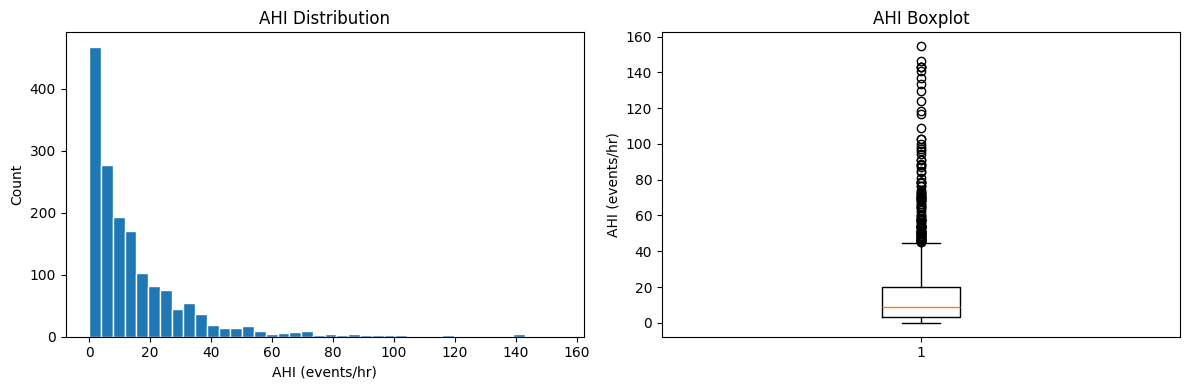

count    1644.00
mean       15.47
std        19.67
min         0.00
25%         3.30
50%         9.10
75%        20.00
max       154.60
Name: apnea_hypopnea_index, dtype: float64


In [65]:
# AHI (target) distribution
ahi = df_display["apnea_hypopnea_index"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ahi, bins=40, edgecolor="white")
axes[0].set_title("AHI Distribution")
axes[0].set_xlabel("AHI (events/hr)")
axes[0].set_ylabel("Count")

axes[1].boxplot(ahi, vert=True)
axes[1].set_title("AHI Boxplot")
axes[1].set_ylabel("AHI (events/hr)")

plt.tight_layout()
plt.show()

print(ahi.describe().round(2))

In [68]:
# sentinel value check: -55 / -66 are STAGES "not applicable" placeholders
# they must be absent at this stage or they'll corrupt downstream imputation

display(check_sentinel_values(df_display))

⚠ 55 column(s) still contain sentinel values (will skew detection):
                                                                                          -55  -66
type_of_pap_device                                                                          9    0
pregnancy_current                                                                           5    0
menopausal_status                                                                         134    0
do_you_use_a_heated_humidifier                                                             13    0
does_your_pap_have_a_heated_tube                                                           16    0
my_current_mask_type                                                                        1    0
my_mask_size                                                                               14    0
family_history_of_insomnia                                                                439    0
family_history_of_sleep_apnea            

,-55,-66
type_of_pap_device,9,0
pregnancy_current,5,0
menopausal_status,134,0
do_you_use_a_heated_humidifier,13,0
does_your_pap_have_a_heated_tube,16,0
my_current_mask_type,1,0
my_mask_size,14,0
family_history_of_insomnia,439,0
family_history_of_sleep_apnea,378,0
family_history_of_narcolepsy,320,0


AHI severity class balance:
  none         555  ( 33.8%)  ████████████████
  mild         539  ( 32.8%)  ████████████████
  moderate     308  ( 18.7%)  █████████
  severe       242  ( 14.7%)  ███████


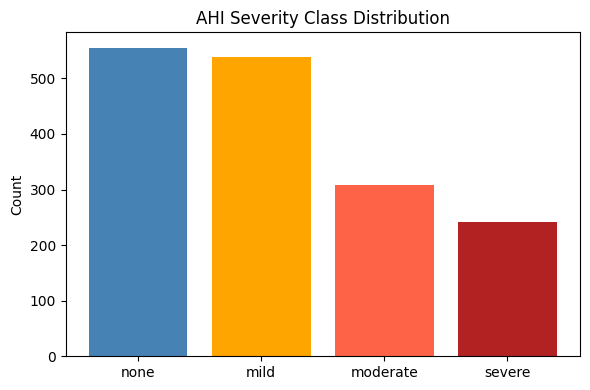

In [67]:
# AHI severity class balance

severity = ahi.map(ahi_to_severity)
counts = severity.value_counts().reindex(["none", "mild", "moderate", "severe"])
pcts = (counts / counts.sum() * 100).round(1)

print("AHI severity class balance:")
for label in counts.index:
    bar = "█" * int(pcts[label] / 2)
    print(f"  {label:10s}  {counts[label]:4d}  ({pcts[label]:5.1f}%)  {bar}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=["steelblue", "orange", "tomato", "firebrick"])
ax.set_title("AHI Severity Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()